<a href="https://colab.research.google.com/github/SOARPN/CUS_752_SPRING_2026/blob/main/Problem_set_03_SVM_Classifer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook is part of Dr. Christoforos Christoforou's course materials. You may not, nor may you knowingly allow others to reproduce or distribute lecture notes, course materials or any of their derivatives without the instructor's express written consent.

# Problem Set 03 - Support Vector Machines Classifiers
**Professor:** Dr. Christoforos Christoforou

For this problem set you will need the following libraries, which are pre-installed with the colab environment:

* [Numpy](https://www.numpy.org/) is an array manipulation library, used for linear algebra, Fourier transform, and random number capabilities.
* [Pandas](https://pandas.pydata.org/) is a library for data manipulation and data analysis.
* [Matplotlib](https://matplotlib.org/) is a library which generates figures and provides graphical user interface toolkit.

You can load them using the following import statement:

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

## 1. Objective
As part of this problem set, you will expore work on the `wine quality dataset`  in order to:
- To explore the physiocochemical properties of red wine
- To determine an optimal machine learning model for red wine quality classification

For that, you will be using an `instance-based` classifier, namely K-NN algorithm. Review the information provided in the problem set, and complete all challenges listed.  

## 2. Wine Quality Dataset - Data Description

For this dataset you will be using the `wine quality dataset`. Below is a description of the various parameters listed in that dataset (i.e. potential features):

* fixed.acidity (tartaric acid - g / dm^3): most acids involved with wine or fixed or nonvolatile (do not evaporate readily)
* volatile.acidity (acetic acid - g / dm^3): the amount of acetic acid in wine, which at too high of levels can lead to an unpleasant, vinegar taste
* citric.acid (g / dm^3): the amount of acetic acid in wine, which at too high of levels can lead to an unpleasant, vinegar taste
* residual.sugar (g / dm^3): the amount of sugar remaining after fermentation stops, it's rare to find wines with less than 1 gram/liter and wines with greater than 45 grams/liter are considered sweet
* chlorides (sodium chloride - g / dm^3): the amount of salt in the wine
* free.sulfur.dioxide (mg / dm^3): the free form of SO2 exists in equilibrium between molecular SO2 (as a dissolved gas) and bisulfite ion; it prevents microbial growth and the oxidation of wine
* total.sulfur.dioxide (mg / dm^3): amount of free and bound forms of S02; in low concentrations, SO2 is mostly undetectable in wine, but at free SO2 concentrations over 50 ppm, SO2 becomes evident in the nose and taste of wine
* density (g / cm^3): the density of water is close to that of water depending on the percent alcohol and sugar content
* pH: describes how acidic or basic a wine is on a scale from 0 (very acidic) to 14 (very basic); most wines are between 3-4 on the pH scale
* sulphates (potassium sulphate - g / dm3): a wine additive which can contribute to sulfur dioxide gas (S02) levels, wich acts as an antimicrobial and antioxidant
* alcohol (% by volume): the percent alcohol content of the wine
* quality: quality score between 0 and 10



## Download dataset from kaggle
You will use the Kaggle CLI to dowload the `Wine Quality Dataset` to your colab enviroment. You will need to upload your kaggle API (see problem_set 01 for direction on how to obtain your API key.

In [29]:
# install kaggle CLI
!pip install -q kaggle

In [30]:
# Upload the kaggle API key of your account
from google.colab import files
files.upload()
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle (2).json
mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [31]:
# View list of data files available in the dataset.
# Format : kaggle dataset files <dataset-URI>
!kaggle datasets files cchristoforou/practice-dataset-for-tutorials

name                       size  creationDate                
-----------------------  ------  --------------------------  
countries.csv              2485  2021-02-25 21:48:51.465000  
country_total.csv        546179  2021-02-25 21:48:51.442000  
dataset_37_diabetes.csv   33824  2021-02-25 21:48:51.881000  
wine.data                 10782  2021-02-25 21:48:51.885000  
wineQualityReds.csv       94286  2021-02-25 21:48:51.458000  


In [32]:
# Download - Specify the parameters.
kaggle_dataset_URI = "cchristoforou/practice-dataset-for-tutorials"
output_folder = "sample_data/problem_set02"
kaggle_data_file1 = "wineQualityReds.csv"

In [33]:
# Download the first file from dataset - countries.csv
!kaggle datasets download $kaggle_dataset_URI --file $kaggle_data_file1 --path $output_folder


Dataset URL: https://www.kaggle.com/datasets/cchristoforou/practice-dataset-for-tutorials
License(s): unknown
wineQualityReds.csv: Skipping, found more recently modified local copy (use --force to force download)


## Load the data
The code below showcase how to load the data in a pandas `DataFrame` and apply a train_test_split on the data.

In [34]:
# Code to load the data from file. Here we use the pandas library to read the csv file.
datafile = "./sample_data/problem_set02/wineQualityReds.csv"
wine_df = pd.read_csv(datafile)
wine_df.drop(wine_df.columns[0],axis=1,inplace=True)

In [36]:
# Split the data into a training and testing set using the sklearn function train_test_split
# Noteice that
X_train, X_test, y_train, y_test = train_test_split(wine_df.drop('quality',axis=1), wine_df['quality'], test_size=.25, random_state=42)


## Challenge 1
Use the variables `X_train`, `X_test`, `y_train`, and `y_test` to explore your data. In particular, calculate and display the following information.

* Number of samples in the training set in total and in each class.
* Number of samples in the testing set in total and in each class.
* Number of features in the dataset.
* Number of classes in the dataset.
* IDs of the number of classes.


In [39]:
print(f"Number of samples in the training set: {len(X_train)}")
print(f"Samples per class in training set:\n{y_train.value_counts().sort_index()}")
print(f"\nNumber of samples in the testing set: {len(X_test)}")
print(f"Samples per class in testing set:\n{y_test.value_counts().sort_index()}")
print(f"\nNumber of features in the dataset: {X_train.shape[1]}")
print(f"Number of classes in the dataset: {len(y_train.unique())}")
print(f"IDs of the classes: {y_train.unique()}")

Number of samples in the training set: 1199
Samples per class in training set:
quality
3      9
4     40
5    517
6    469
7    151
8     13
Name: count, dtype: int64

Number of samples in the testing set: 400
Samples per class in testing set:
quality
3      1
4     13
5    164
6    169
7     48
8      5
Name: count, dtype: int64

Number of features in the dataset: 11
Number of classes in the dataset: 6
IDs of the classes: [5 7 6 4 8 3]


# Challenge 2

Train a **SVM** classifier using the `(X_train,y_train)` dataset and use the trained model to predict the underlying classes for the observations in the test dataset `X_test`. Store your prediction in a variable called `y_pred`.

In [43]:
from sklearn.svm import SVC

# Create an SVM classifier
svm_classifier = SVC()

# Train the classifier
svm_classifier.fit(X_train, y_train)

y_pred = svm_classifier.predict(X_test)

# Challenge 3

Evaluate the performance of your classifier. Calculate and display the following:
* print the `confusion matrix`.
* `normalized confusion matrix`.
* the probablitity of correct classification (accuracy score).
* the `precision`, `recall`, and `f1-score` for each class.

In [53]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')

print("Normalized Confusion Matrix:")
print(cm_normalized)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred, average=None)
recall = recall_score(y_test, y_pred, average=None)
f1 = f1_score(y_test, y_pred, average=None)

print("Precision per class:", precision)
print("Recall per class:", recall)
print("F1-score per class:", f1)

Confusion Matrix:
[[  0   0   0   1   0   0]
 [  0   0   2  11   0   0]
 [  0   0  83  81   0   0]
 [  0   0  49 120   0   0]
 [  0   0   5  42   1   0]
 [  0   0   1   4   0   0]]
Normalized Confusion Matrix:
[[0.         0.         0.         1.         0.         0.        ]
 [0.         0.         0.15384615 0.84615385 0.         0.        ]
 [0.         0.         0.50609756 0.49390244 0.         0.        ]
 [0.         0.         0.28994083 0.71005917 0.         0.        ]
 [0.         0.         0.10416667 0.875      0.02083333 0.        ]
 [0.         0.         0.2        0.8        0.         0.        ]]
Accuracy: 0.51
Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        13
           5       0.59      0.51      0.55       164
           6       0.46      0.71      0.56       169
           7       1.00      0.02      0.04        48
           8

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

# Challenge 4

The code below loads the same dataset, but treats it as a binary classification problem. That is, instead of classifying an observation into one of 10 categories (0..10), we consider all observations with score above 5 as being good and all observation below or equal to five as being bad.





In [55]:
# Code to load the data from file. Here we use the pandas library to read the csv file.
datafile = "./sample_data/problem_set02/wineQualityReds.csv"
wine_df = pd.read_csv(datafile)
wine_df.drop(wine_df.columns[0],axis=1,inplace=True)

wine_df['quality'] = np.where(wine_df['quality']>5,"Good","Bad")

In [56]:
X_train, X_test, y_train, y_test = train_test_split(wine_df.drop('quality',axis=1), wine_df['quality'], test_size=.25, random_state=42)


## Callenge 4.1
Use the variables `X_train`, `X_test`, `y_train`, and `y_test` to explore your data. In particular, calculate and display the following information.
* Number of samples in the training set in total and in each class.
* Number of samples in the testing set in total and in each class.
* Number of features in the dataset.
* Number of classes in the dataset.
* IDs of the number of classes.




In [57]:
# Your Solution
print(f"Number of samples in the training set: {len(X_train)}")
print(f"Samples per class in training set:\n{y_train.value_counts().sort_index()}")
print(f"\nNumber of samples in the testing set: {len(X_test)}")
print(f"Samples per class in testing set:\n{y_test.value_counts().sort_index()}")
print(f"\nNumber of features in the dataset: {X_train.shape[1]}")
print(f"Number of classes in the dataset: {len(y_train.unique())}")
print(f"IDs of the classes: {y_train.unique()}")

Number of samples in the training set: 1199
Samples per class in training set:
quality
Bad     566
Good    633
Name: count, dtype: int64

Number of samples in the testing set: 400
Samples per class in testing set:
quality
Bad     178
Good    222
Name: count, dtype: int64

Number of features in the dataset: 11
Number of classes in the dataset: 2
IDs of the classes: ['Bad' 'Good']


## Challenge 4.2
Train a **Support Vector Machine** classifier using the `(X_train,y_train)` dataset and use trained model to predict the underlying classes for the observations in the test dataset `X_test`. Store your prediction in a variable called `y_pred`.

In [58]:
from sklearn.svm import SVC

# Create an SVM classifier for the binary classification problem
svm_classifier_binary = SVC()

# Train the classifier
svm_classifier_binary.fit(X_train, y_train)

y_pred = svm_classifier_binary.predict(X_test)

## Challenge 4.3
Evaluate the performance of your classifier. Calculate and display the following:
* print the `confusion matrix`.
* `normalized confusion matrix`.
* the probablitity of correct classification (accuracy score).
* the `precision`, `recall`, and `f1-score` for each class.

Confusion Matrix (Binary Classification):
 [[ 65 113]
 [ 32 190]]

Normalized Confusion Matrix (Binary Classification):
 [[0.36516854 0.63483146]
 [0.14414414 0.85585586]]


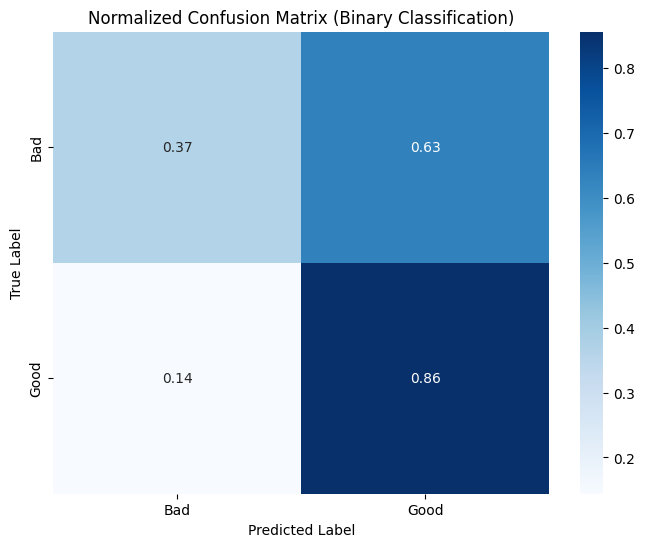


Accuracy Score (Binary Classification): 0.6375

Precision, Recall, F1-score per Class (Binary Classification):



,Class,Precision,Recall,F1-Score
0,Bad,0.670103,0.365169,0.472727
1,Good,0.627063,0.855856,0.723810


In [59]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate confusion matrix
conf_matrix_binary = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (Binary Classification):\n", conf_matrix_binary)

# Calculate normalized confusion matrix
normalized_conf_matrix_binary = conf_matrix_binary.astype('float') / conf_matrix_binary.sum(axis=1)[:, np.newaxis]
print("\nNormalized Confusion Matrix (Binary Classification):\n", normalized_conf_matrix_binary)

# Plotting normalized confusion matrix for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(normalized_conf_matrix_binary, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=svm_classifier_binary.classes_, yticklabels=svm_classifier_binary.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normalized Confusion Matrix (Binary Classification)')
plt.show()

# Calculate accuracy score
accuracy_binary = accuracy_score(y_test, y_pred)
print(f"\nAccuracy Score (Binary Classification): {accuracy_binary:.4f}")

# Calculate precision, recall, and f1-score for each class
precision_binary, recall_binary, f1_score_binary, _ = precision_recall_fscore_support(y_test, y_pred, average=None, labels=svm_classifier_binary.classes_)

performance_df_binary = pd.DataFrame({
    'Class': svm_classifier_binary.classes_,
    'Precision': precision_binary,
    'Recall': recall_binary,
    'F1-Score': f1_score_binary
})

print("\nPrecision, Recall, F1-score per Class (Binary Classification):\n")
display(performance_df_binary)

# Challenge 5

The **SVM** classifier accepts a number of parameters. These parameters include the parameter `C` (i.e. the regularization parameter), the `kernel` which specified the kernel function to be used, and the parameter `gamma` which can be used to specify the kernel coefficents for certain kernels (i.e. `rbf`, `poly` and `sigmoid`). You can find more information about the various parameters in implementation of the SVM classifier on the following website:

- [SVM documentation on sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC)
- [User Guide on Support Vector Machines](https://scikit-learn.org/stable/modules/svm.html#svm-classification)
- [Kernel Function Supported by sklearn library](https://scikit-learn.org/stable/modules/svm.html#svm-kernels)


After reading the documentation to understand how the various parameters are used, evaluate the classifier for different values of C, gamma and kernel parameters and identify which configuration achieve the best performance on the testing set. Plot or print your results.


In [1]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline # Corrected: Added Pipeline import
from sklearn.preprocessing import StandardScaler # Corrected: Added StandardScaler import

# Define the parameter grid for GridSearchCV
param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': ['scale', 'auto', 0.1, 1],
    'svc__kernel': ['rbf', 'linear', 'poly', 'sigmoid']
}

# Create a pipeline with StandardScaler and SVC
# The names in the param_grid ('svc__C', etc.) refer to steps in this pipeline.
svm_pipeline = Pipeline([('scaler', StandardScaler()), ('svc', SVC())])

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    cv=3,  # Using 3-fold cross-validation
    n_jobs=-1, # Use all available cores
    verbose=2, # Verbose output
    scoring='accuracy' # Optimize for accuracy
)

# Fit GridSearchCV to the training data
print("Starting GridSearchCV...")
grid_search.fit(X_train, y_train)
print("GridSearchCV finished.")

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"\nBest parameters found: {best_params}")
print(f"Best cross-validation accuracy: {best_score:.4f}")

# Get the best estimator (model)
best_svm_model = grid_search.best_estimator_

# Evaluate the best model on the test set
y_pred_best = best_svm_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_best)

print(f"\nTest set accuracy with best parameters: {test_accuracy:.4f}")
print("\nClassification Report for the best model on test set:\n")
print(classification_report(y_test, y_pred_best))

Starting GridSearchCV...


NameError: name 'X_train' is not defined


Copyright Statement: Copyright © 2020 Christoforou. The materials provided by the instructor of this course, including this notebook, are for the use of the students enrolled in the course. Materials are presented in an educational context for personal use and study and should not be shared, distributed, disseminated or sold in print — or digitally — outside the course without permission. You may not, nor may you knowingly allow others to reproduce or distribute lecture notes, course materials as well as any of their derivatives without the instructor's express written consent.